In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

In [2]:
df = pd.read_csv("real-estate.csv")

features = [
    "Prix",
    "Surface",
    "Nb_Pieces",
    "Age_Bien"
]

X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dimensions :", df.shape)
df.head()

Dimensions : (50, 5)


,Property_ID,Prix,Surface,Nb_Pieces,Age_Bien
0,P1,1386880,238,1,11
1,P2,804999,282,5,12
2,P3,631593,196,5,12
3,P4,2355723,125,2,28
4,P5,2548988,58,1,14


In [3]:
def suggest_figsize(n_obs, base_width=12, base_height=5):
    """Suggère automatiquement une taille de figure selon le nombre d'observations."""
    width = min(22, max(base_width, n_obs / 12))
    height = min(9, max(base_height, 4 + math.log10(max(n_obs, 10))))
    return (round(width, 1), round(height, 1))

figsize_auto = suggest_figsize(len(X_scaled))
print('Figure suggérée pour le dendrogramme :', figsize_auto)


Figure suggérée pour le dendrogramme : (12, 5.7)


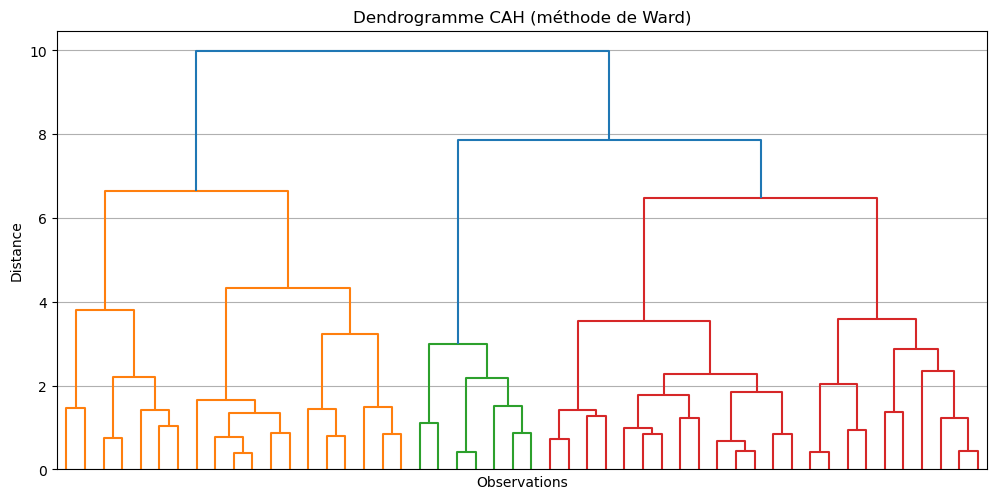

In [4]:
Z = linkage(X_scaled, method="ward", metric="euclidean")

plt.figure(figsize=figsize_auto)
dendrogram(Z, no_labels=True)
plt.title("Dendrogramme CAH (méthode de Ward)")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.grid(True)
plt.show()


In [5]:
results = []

for k in range(4, 5):
    labels = fcluster(Z, t=k, criterion="maxclust")
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    results.append((k, sil, db))

results_df = pd.DataFrame(results, columns=["K", "Silhouette", "Davies_Bouldin"])
print(results_df)

best_k = int(results_df.loc[results_df["Silhouette"].idxmax(), "K"])
print("\nNombre de clusters proposé automatiquement :", best_k)

   K  Silhouette  Davies_Bouldin
0  4    0.247278        1.128618

Nombre de clusters proposé automatiquement : 4


In [6]:
n_clusters = int(best_k)
cah_labels = fcluster(Z, t=n_clusters, criterion="maxclust")

df["Cluster_CAH"] = cah_labels

print("Profil moyen par cluster :")
display(df.groupby("Cluster_CAH")[features].mean().round(2))

<class 'NameError'>: name 'cah_labels' is not defined

In [ ]:
methods_to_compare = [
    ("ward", "euclidean"),
    ("complete", "euclidean"),
    ("average", "euclidean"),
    ("complete", "cityblock"),   # Manhattan
    ("average", "cosine")
]

comparison_results = []

for method, metric in methods_to_compare:
    Z_tmp = linkage(X_scaled, method=method, metric=metric)
    labels_tmp = fcluster(Z_tmp, t=best_k if 'best_k' in globals() else 4, criterion="maxclust")
    sil_tmp = silhouette_score(X_scaled, labels_tmp)
    db_tmp = davies_bouldin_score(X_scaled, labels_tmp)
    comparison_results.append((method, metric, sil_tmp, db_tmp))

comparison_df = pd.DataFrame(
    comparison_results,
    columns=["Methode", "Distance", "Silhouette", "Davies_Bouldin"]
)
comparison_df.sort_values(by="Silhouette", ascending=False)
n_clusters = int(best_k)
cah_labels = fcluster(Z, t=n_clusters, criterion="maxclust")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cah_labels, s=30, alpha=0.8)
plt.title(f"CAH avec {n_clusters} clusters (choisi automatiquement)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [ ]:
n_clusters = int(best_k)
cah_labels = fcluster(Z, t=n_clusters, criterion="maxclust")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cah_labels, s=30, alpha=0.8)
plt.title(f"CAH avec {n_clusters} clusters (choisi automatiquement)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [7]:
sil_final = silhouette_score(X_scaled, cah_labels)
db_final = davies_bouldin_score(X_scaled, cah_labels)

print("Silhouette finale :", round(sil_final, 4))
print("Davies-Bouldin final :", round(db_final, 4))

<class 'NameError'>: name 'cah_labels' is not defined

In [8]:
df["Cluster_CAH"] = cah_labels

print("Profil moyen par cluster :")
display(df.groupby("Cluster_CAH")[features].mean().round(2))

<class 'NameError'>: name 'cah_labels' is not defined